# Исследовательский анализ данных рынка общественного питания Москвы

- Автор: Шумилин Андрей Иванович
- Дата: 02.06.2026

### Цели и задачи проекта

Основная цель проекта состоит в получении обоснованных выводов и рекомендаций для инвесторов из фонда Shut Up and Take My Money на основе исследовательского анализа данных о рынке общественного питания Москвы. Заказчик хочет открыть заведение такого типа и местоположения, чтобы максимизировать прибыль.

Задачи:  
1) Загрузить данные и познакомиться с ними    
2) Провести предобработку данных   
3) Провести исследовательский анализ данных  
4) Сформировать выводы и рекомендации про проведенному анализу

### Описание данных


Файл `/datasets/rest_info.csv` содержит информацию о заведениях общественного питания:  
`name` — название заведения;  
`address` — адрес заведения;  
`district` — административный район, в котором находится заведение, например Центральный административный округ;  
`category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;  
`hours` — информация о днях и часах работы;  
`rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);  
`chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):  
0 — заведение не является сетевым;  
1 — заведение является сетевым.  
`seats` — количество посадочных мест.

Файл `/datasets/rest_price.csv` содержит информацию о среднем чеке в заведениях общественного питания:  
`price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;  
`avg_bill` — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:  
«Средний счёт: 1000–1500 ₽»;  
«Цена чашки капучино: 130–220 ₽»;  
«Цена бокала пива: 400–600 ₽».  
и так далее;  
`middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Средний счёт»:  
Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.  
Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.  
Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.  
`middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Цена одной чашки капучино»:  
Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.  
Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.  
Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт. 

### Содержимое проекта

Шаги проекта:
1) Загрузить данные и познакомиться с ними    
2) Провести предобработку данных   
3) Провести исследовательский анализ данных  
4) Сформировать выводы и рекомендации про проведенному анализу

## 1. Загрузка данных и знакомство с ними

In [2]:
# В проекте понадобится рассчитать матрицу корреляции, поэтому установим соответствующую библиотеку
import warnings
warnings.filterwarnings("ignore")
!pip install phik -U   

In [3]:
# Импортируем все библиотеки, которые нужны в проекте
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix 

In [4]:
# Прочитаем файлы в датафреймы
rest_df = pd.read_csv('Desktop/rest_info.csv')
price_df = pd.read_csv('Desktop/rest_price.csv')

In [5]:
rest_df.info()
rest_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [6]:
price_df.info()
price_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


---

### Промежуточный вывод

Вывод по датафрейму `rest_df`:    

датафрейм содержит 8406 строк, количество столбцов 9. Данные соответствуют описанию. Пропуски встречаются только в столбце `hours` (7870 ненулевых значений из 8406 строк) и в `seats` (4795 ненулевых из 8406 строк). Типы данных практически везде используются верные, кроме столбца `chain`, в котором стоит лишь уменьшить объем хранимой памяти с 64 до 8, так как он принимает значения либо 0, либо 1, а столбец `seats` привести к типу данных `int`, ведь количество посадочных мест не может быть дробным. Названия столбцов оформлены в `snake_case`, поэтому приводить их в такой стиль нет необходимости. 

Вывод по датафрейму `price_df`:

датафрейм содержит 4058 строк и 5 столбцов. Данные соответствуют описанию. Пропуски есть во всех столбцах, кроме `id`: в столбце `price` 3315 непустых строк из 4058, в столбце `avg_bill` - 3816, в `middle_avg_bill` еще меньше, а именно 3149 непустых строк, в `middle_coffee_cup` - 535 строк без пропусков. Типы данных для столбцов выбраны корректно. К `snake_case` приведены все столбцы.

### Подготовка единого датафрейма

In [7]:
df = pd.merge(rest_df, price_df, on='id', how='left')

In [8]:
df

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8401,0342ad1a45ed41ba89dcba246a8267e5,Суши Мания,кафе,"Москва, Профсоюзная улица, 56",Юго-Западный административный округ,"ежедневно, 09:00–02:00",4.4,0,86.0,NaN,NaN,NaN,NaN
8402,ee6bb7c3650e47bd8186fca08eda1091,Миславнес,кафе,"Москва, Пролетарский проспект, 19, корп. 1",Южный административный округ,"ежедневно, 08:00–22:00",4.8,0,150.0,NaN,NaN,NaN,NaN
8403,62e8c64d4c89467aba608e39ef87616b,Самовар,кафе,"Москва, Люблинская улица, 112А, стр. 1",Юго-Восточный административный округ,"ежедневно, круглосуточно",3.9,0,150.0,NaN,Средний счёт:от 150 ₽,150.0,NaN
8404,06a0db5ecd4842d48cd6350aa923e297,Чайхана Sabr,кафе,"Москва, Люблинская улица, 112А, стр. 1",Юго-Восточный административный округ,"ежедневно, круглосуточно",4.2,1,150.0,NaN,NaN,NaN,NaN


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


In [10]:
# Перед предобработкой данных сделаем контроль размера датасета до обработки
temp = df.copy() 
len(temp)

8406

## 2. Предобработка данных

In [11]:
# Заменим пропуски в столбце seats на значение-индикатор -1, чтобы можно было привести к типу данных int8
df = df.fillna({'seats': -1})

In [12]:
df = df.astype({'chain': 'int8', 'seats': 'int64'})

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int8   
 8   seats              8406 non-null   int64  
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(3), int64(1), int8(1), object(8)
memory usage: 861.9+ KB


In [14]:
# Понизим разрядность числовых данных с 64 до 32
for column in ['rating','middle_avg_bill','middle_coffee_cup']:
    df[column] = pd.to_numeric(df[column], downcast='float')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float32
 7   chain              8406 non-null   int8   
 8   seats              8406 non-null   int64  
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float32
 12  middle_coffee_cup  535 non-null    float32
dtypes: float32(3), int64(1), int8(1), object(8)
memory usage: 763.4+ KB


In [16]:
# Посмотрим на пропуски
print(f'Абсолютное количество пропусков в столбце hours: {df["hours"].isna().sum()}')
print(f'Абсолютное количество пропусков в столбце price: {df["price"].isna().sum()}')
print(f'Абсолютное количество пропусков в столбце avg_bill: {df["avg_bill"].isna().sum()}')
print(f'Абсолютное количество пропусков в столбце middle_avg_bill: {df["middle_avg_bill"].isna().sum()}')
print(f'Абсолютное количество пропусков в столбце middle_coffee_cup: {df["middle_coffee_cup"].isna().sum()}')

Абсолютное количество пропусков в столбце hours: 536
Абсолютное количество пропусков в столбце price: 5091
Абсолютное количество пропусков в столбце avg_bill: 4590
Абсолютное количество пропусков в столбце middle_avg_bill: 5257
Абсолютное количество пропусков в столбце middle_coffee_cup: 7871


In [17]:
print(f'Абсолютное количество пропусков в столбце hours: {df["hours"].isna().sum()}')
print(f'Абсолютное количество пропусков в столбце price: {df["price"].isna().sum()}')
print(f'Абсолютное количество пропусков в столбце avg_bill: {df["avg_bill"].isna().sum()}')
print(f'Абсолютное количество пропусков в столбце middle_avg_bill: {df["middle_avg_bill"].isna().sum()}')
print(f'Абсолютное количество пропусков в столбце middle_coffee_cup: {df["middle_coffee_cup"].isna().sum()}')

Абсолютное количество пропусков в столбце hours: 536
Абсолютное количество пропусков в столбце price: 5091
Абсолютное количество пропусков в столбце avg_bill: 4590
Абсолютное количество пропусков в столбце middle_avg_bill: 5257
Абсолютное количество пропусков в столбце middle_coffee_cup: 7871


- В столбце `hours` 6% (536) данных отсутствует, скорее всего, это полностью случайные пропуски, их можно либо оставить в принципе, либо заполнить значением `uknown`, чтобы просто знать, где указано, а где нет, удалять нельзя - потеряется значительная часть данных
- В столбце `price` 61% (5091) всех данных содержит пропуски, это очень много. Скорее всего это неслучайные пропуски, которые объясняются данными, не содержащимися в нашем наборе (может быть все зависит от популярности заведения). Так или иначе пропуски не имеет смысла удалять или чем-то заменять - произойдет сильнейшее искажение. Для расчетов фильтровать датафрейм, чтобы пропуски не включались в выборку
- В столбце `avg_bill` 55% (4590) всех данных являются пропусками, это также много, ситуация схожа с прошлым столбцом, здесь неслучайные пропуски, которые нельзя объяснить данными в актуальном наборе. Процент большой, поэтому оставим как есть
- В столбце `middle_avg_bill` 63% (5257) всех данных являются пропущенными, при этом понятно следующее: не все заведения, из тех, что указали диапазон цен, имеют в `avg_bill` подстроку `Средний счет`, где-то указан средний чек для чашки кофе и т.д. Тоже слишком большой процент пропущенных значений, а значит мы не будем трогать этот столбец вообще
- В столбце `middle_coffee_cup` 94% (7871) всех данных являются пропущенными, причина пропусков здесь та же, как и в прошлом столбце, не везде в `avg_bill` есть подстрока `Цена одной чашки капучино`. Трогать не будем, очень много пропусков.

In [18]:
# Столбец 'seats'
print((df['seats'] == -1).sum())
(df['seats'] == -1).sum() / len(df)
# Пропуски были заменены на -1, чтобы была возможность привести в другому типу данных. 
# Причина пропусков, скорее всего, кроется в непопулярности некоторых заведений, и количество посадочных мест для них просто не указано или руководство не видит необходимости указывать число мест.

3611


0.4295741137282893

In [19]:
df

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,-1,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,-1,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148,средние,Средний счёт:400–600 ₽,500.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8401,0342ad1a45ed41ba89dcba246a8267e5,Суши Мания,кафе,"Москва, Профсоюзная улица, 56",Юго-Западный административный округ,"ежедневно, 09:00–02:00",4.4,0,86,NaN,NaN,NaN,NaN
8402,ee6bb7c3650e47bd8186fca08eda1091,Миславнес,кафе,"Москва, Пролетарский проспект, 19, корп. 1",Южный административный округ,"ежедневно, 08:00–22:00",4.8,0,150,NaN,NaN,NaN,NaN
8403,62e8c64d4c89467aba608e39ef87616b,Самовар,кафе,"Москва, Люблинская улица, 112А, стр. 1",Юго-Восточный административный округ,"ежедневно, круглосуточно",3.9,0,150,NaN,Средний счёт:от 150 ₽,150.0,NaN
8404,06a0db5ecd4842d48cd6350aa923e297,Чайхана Sabr,кафе,"Москва, Люблинская улица, 112А, стр. 1",Юго-Восточный административный округ,"ежедневно, круглосуточно",4.2,1,150,NaN,NaN,NaN,NaN


In [20]:
#Заменим в столбце `hours` отсутствующие данные на 'uknown'
df['hours'] = df['hours'].fillna('uknown')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              8406 non-null   object 
 6   rating             8406 non-null   float32
 7   chain              8406 non-null   int8   
 8   seats              8406 non-null   int64  
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float32
 12  middle_coffee_cup  535 non-null    float32
dtypes: float32(3), int64(1), int8(1), object(8)
memory usage: 763.4+ KB


В остальных столбцах слишком много пропусков, мы просто будем учитывать это при исследовательском анализе данных, то есть сейчас заменять пропуски не будем.

In [22]:
columns = ['name', 'category']
def unique_values(columns):
    for column in ['name', 'category']:
        print(f'Уникальные значения в столбце {column}:')
        print(df[column].sort_values().unique())
        print(f'Всего уникальных значений: {df[column].nunique()}')
        print()
unique_values(columns)

Уникальные значения в столбце name:
['#КешбэкКафе' '+39 Pizzeria Mozzarella bar' '1 Этаж' ... 'Ясно' 'Яуза'
 'ночной Баку']
Всего уникальных значений: 5614

Уникальные значения в столбце category:
['бар,паб' 'булочная' 'быстрое питание' 'кафе' 'кофейня' 'пиццерия'
 'ресторан' 'столовая']
Всего уникальных значений: 8



In [23]:
df.duplicated().sum()

0

In [24]:
#Нормализуем названия и адреса
df['name'] = df['name'].str.lower().str.strip()
df['address'] = df['address'].str.lower().str.strip()

In [25]:
#Явные дубликаты по нормализованным названию и адресу
duplicates = df.duplicated(subset=['name', 'address']).sum()
print(f"Дубликатов по названию и адресу: {duplicates}")
df[df.duplicated(subset=['name', 'address'])]

Дубликатов по названию и адресу: 4


,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 10:00–22:00",3.2,0,-1,NaN,NaN,NaN,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188,NaN,NaN,NaN,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",Северо-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150,NaN,NaN,NaN,NaN
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"москва, ярцевская улица, 19",Западный административный округ,uknown,4.1,0,276,NaN,NaN,NaN,NaN


In [26]:
#Удалим явные дубликаты
df = df.drop_duplicates(subset=['name', 'address'])

In [27]:
#Проверим наличие дубликатов во всем датафрейме
dup = df.duplicated()
print(f"Строк-дубликатов: {dup.sum()}")

Строк-дубликатов: 0


In [32]:
def work(hours):
    if hours == 'ежедневно, круглосуточно':
        return True
    else:
        return False
df.loc[:, 'is_24_7'] = df['hours'].apply(work)  
df['is_24_7'].value_counts()

False    7672
True      730
Name: is_24_7, dtype: int64

In [33]:
# Проверим сколько удалено строк датасета
a, b = len(temp), len(df)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в исходном датасете 8406 
 Осталось строк в датасете после обработки 8402 
 Удалено строк в датасете после обработки 4 
 Процент потерь 0.05


---

### Промежуточный вывод

1. Общая информация о данных

- Размер исхожного (объединенного) датасета (8406 строк × 9 столбцов)
- Размер после предобработки 8402 строки × 9 столбцов
- Предоставленные данные - информация о заведениях Москвы во всех административных районах города

2. Типы данных

- Приведены типы: в столбце `rating` была понижена разрядность с 64 до 32, в столбце `chain` была также понижена разрядность с 64 до 8, а в столбцах `middle_avg_bill` и `middle_coffee_cup` разрядность была понижена с 64 до 32.
- Все колонки имеют корректные типы данных, поэтому прямого преобразования в более подходящий тип данных не потребовалось

3. Пропуски

- Количество пропусков до обработки: в столбце `hours`: 536, `price`: 5091, в столбце `avg_bill`: 4590,  в столбце `middle_avg_bill`: 5257, в столбце `middle_coffee_cup`: 7871
- Метод обработки - в столбце `hours` замена на значение-индикатор `uknown`, в столбце `seats` тоже на значение-индикатор `-1`, но только временно, чтобы была возможность поменять тип данных
- Количество пропусков после обработки: `price`: 5091, в столбце `avg_bill`: 4590,  в столбце `middle_avg_bill`: 5257, в столбце `middle_coffee_cup`: 7871

4. Дубликаты

- Количество полных дубликатов: до нормализации 0, после - 0

- Количество дубликатов по ключевым полям `name` и `address`: 4

- Метод обработки: удаление

- После обработки остались все 9 столбцов, но при этом 8402 строки из 8406

5. Информация о создании доп. столбцов

- Был создан столбец `is_24_7`, который показывает, работает ли заведение круглосуточно и ежедневно: `True` в случае работы круглосуточно и ежедневно, `False` - в противном случае

6. Итоговое состояние данных

- Количество строк после всех преобразований - 8402

- После проведенной предобработки данные полностью готовы к анализу

### Шаг 3. Исследовательский анализ данных

### Задача 1

Посмотрим, какие категории заведений представлены в данных? Исследуем количество объектов общественного питания по каждой категории. Результат сопроводим подходящей визуализацией.

In [36]:
print('Распределение данных по уникальным значениям столбца category:')
df['category'].value_counts(normalize=True)

Распределение данных по уникальным значениям столбца category:


кафе               0.282790
ресторан           0.243037
кофейня            0.168174
бар,паб            0.090931
пиццерия           0.075339
быстрое питание    0.071769
столовая           0.037491
булочная           0.030469
Name: category, dtype: float64

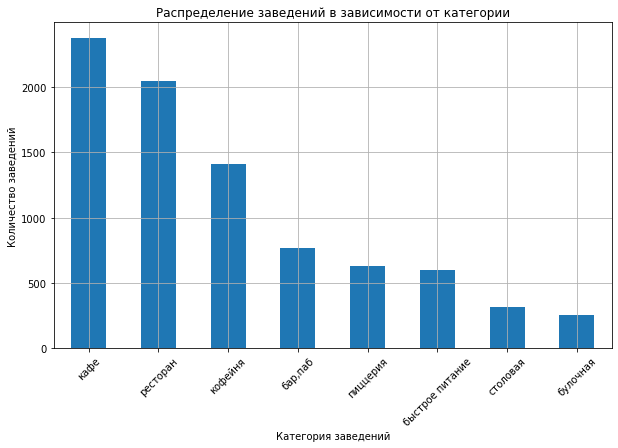

In [37]:
plt.figure(figsize=(10, 6))
df['category'].value_counts().plot(
               kind='bar',
               rot=45,
               legend=False,
               title='Распределение заведений в зависимости от категории')
plt.xlabel('Категория заведений')
plt.ylabel('Количество заведений')
plt.grid()
plt.show()

1. <b>Группировка и интерпретация</b><br>
- Рынок общепита Москвы не монолитен: <b>кафе и рестораны суммарно занимают более половины всех заведений (52.5%)</b>. Однако, если объединить их с кофейнями и барами, получится, что <b>~78% точек</b> относятся к форматам, ориентированным на <b>длительное времяпрепровождение</b> (посидеть, поработать, встретиться).<br>

2. <b>Сравнение и бизнес-смысл</b>
-   <b>Кафе (28%)</b> и <b>Рестораны (24%)</b> — абсолютные лидеры. Это «золотая середина»: первый привлекает демократичностью, второй — статусом.
-   <b>Кофейни (17%)</b> — третий по величине сегмент, что подтверждает тренд на «кофе с собой» и коворкинг.
-   <b>Бары (9%)</b> замыкают топ-4, показывая стабильный, но более узкий спрос на вечерний досуг.
-   <b>Быстрое питание (7%)</b> и <b>Столовые (3.7%)</b> находятся в минорной позиции, что говорит о высокой конкуренции со стороны уличной еды и форматов «готового обеда» в магазинах.<br>

3. <b>Рекомендации</b>
-   <b>Для массового трафика:</b> Открывать <b>кафе</b> (универсальный формат) или <b>кофейню</b> (быстрая окупаемость).
-   <b>Для высокой маржи:</b> Внедрять гибридные форматы (кофейня-пекарня, ресторан-бар), чтобы захватить аудиторию нескольких сегментов.
-   <b>Аутсайдерам (столовые, бургерные):</b> Выход в спальные районы с высоким пешеходным трафиком, где спрос на «дешевый обед» остается неудовлетворённым из-за удаленности от офисов.</font>

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуем распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводим подходящими визуализациями.

In [38]:
df['district'].value_counts(normalize=True)

Центральный административный округ         0.266841
Северный административный округ            0.106879
Южный административный округ               0.106165
Северо-Восточный административный округ    0.105927
Западный административный округ            0.101166
Восточный административный округ           0.094977
Юго-Восточный административный округ       0.084980
Юго-Западный административный округ        0.084385
Северо-Западный административный округ     0.048679
Name: district, dtype: float64

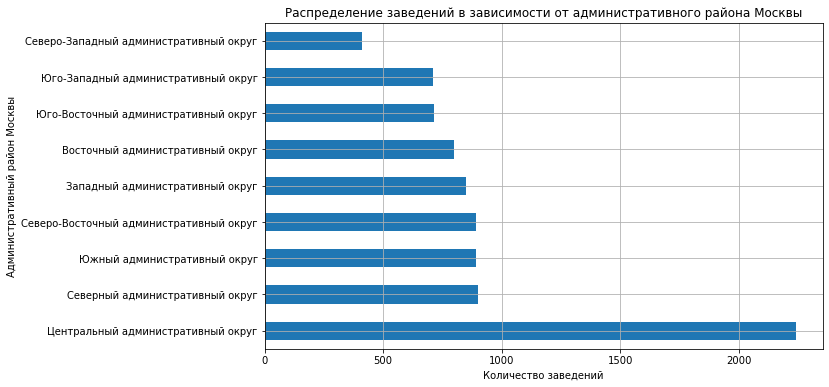

In [39]:
plt.figure(figsize=(10, 6))
df['district'].value_counts().plot(
               kind='barh',
               rot=0,
               legend=False,
               title='Распределение заведений в зависимости от административного района Москвы')
plt.xlabel('Количество заведений')
plt.ylabel('Административный район Москвы')
plt.grid()
plt.show()

In [40]:
df_central_share = df[df['district'] == 'Центральный административный округ']
df_central_share['category'].value_counts(normalize=True)

ресторан           0.298840
кафе               0.206958
кофейня            0.190901
бар,паб            0.162355
пиццерия           0.050401
быстрое питание    0.038805
столовая           0.029438
булочная           0.022302
Name: category, dtype: float64

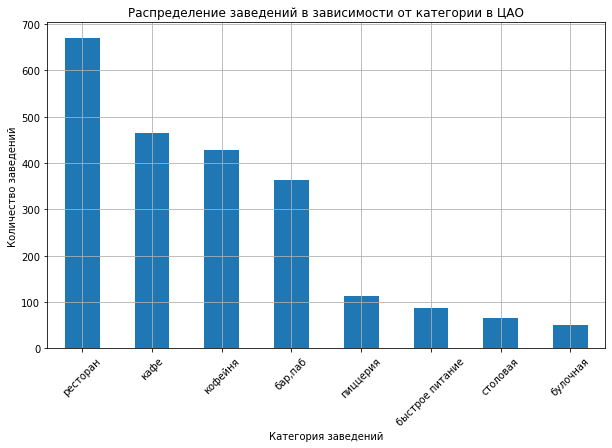

In [41]:
df_central = df[df['district'] == 'Центральный административный округ']
plt.figure(figsize=(10, 6))
df_central['category'].value_counts().plot(
               kind='bar',
               rot=45,
               legend=False,
               title='Распределение заведений в зависимости от категории в ЦАО')
plt.xlabel('Категория заведений')
plt.ylabel('Количество заведений')
plt.grid()
plt.show()

- Если обратить внимание на распределение заведений в зависимости от административного района Москвы, можно увидеть, что наибольшее количество заведений (с большим отрывом) находится именно в ЦАО, между остальными районами не такая большая разница, кроме Северо-Западного административного округа, там гораздо меньше заведений, чем в любом другом районе Москвы.
- Что касается распределения заведений в зависимости от категории в ЦАО, то в нем лидером по популярности стала категория `ресторан`, что говорит о востребованности данного типа заведения в центре Москвы; категории `кафе`, `кофейня` и `бар, паб` примерно в равном количестве (с небольшой разницей) находятся на втором месте по популярности, а вот категории `пиццерия`, `быстрое питание`, `столовая`,  `булочная` имеют минимальную распространенность в ЦАО.

### Задача 3

Изучим соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуем данные, ответим на вопросы и построим необходимые визуализации.

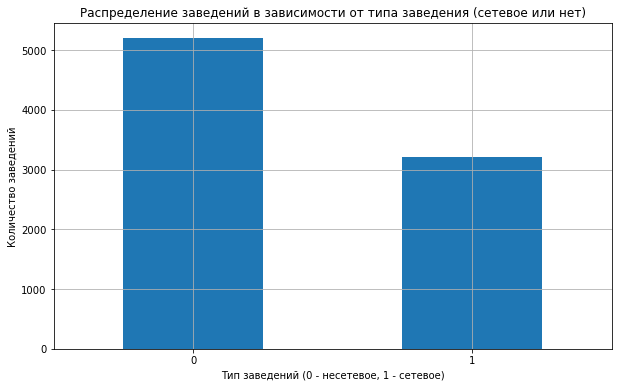

In [42]:
plt.figure(figsize=(10, 6))
df['chain'].value_counts().plot(
            kind='bar',
            rot=0,
            legend=False,
            title="Распределение заведений в зависимости от типа заведения (сетевое или нет)")
plt.xlabel("Тип заведений (0 - несетевое, 1 - сетевое)")
plt.ylabel('Количество заведений')
plt.grid()
plt.show()

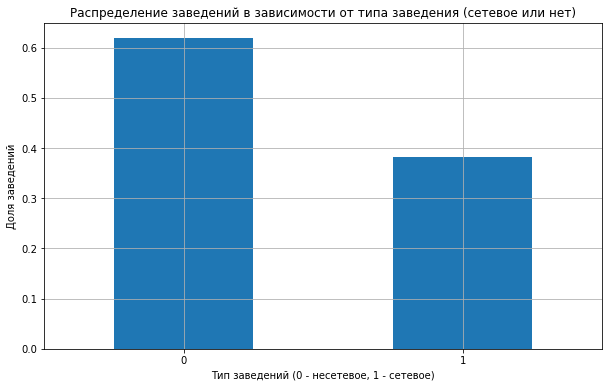

In [43]:
plt.figure(figsize=(10, 6))
df['chain'].value_counts(normalize=True).plot(
            kind='bar',
            rot=0,
            legend=False,
            title="Распределение заведений в зависимости от типа заведения (сетевое или нет)")
plt.xlabel("Тип заведений (0 - несетевое, 1 - сетевое)")
plt.ylabel('Доля заведений')
plt.grid()
plt.show()

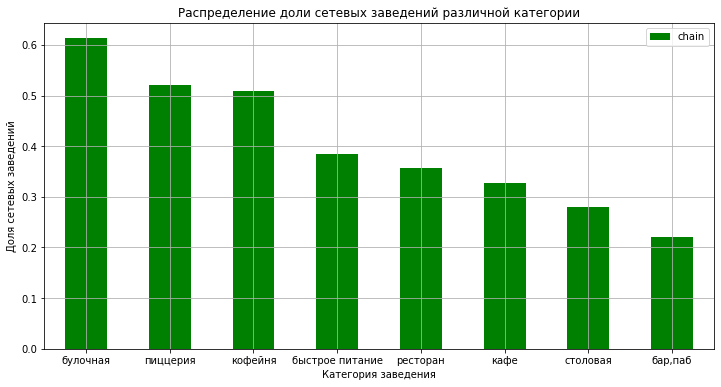

In [44]:
grouped = df.groupby('category')['chain'].mean().sort_values(ascending=False)
grouped.plot(kind='bar',
             rot=0,
             legend=True,
             figsize=(12, 6),
             color='green',
             title="Распределение доли сетевых заведений различной категории")
plt.xlabel('Категория заведения')
plt.ylabel('Доля сетевых заведений')
plt.grid()
plt.show()

- Несетевых заведений больше в среднем на 2000 штук (если смотреть по всем данным).
- Больше всего сетевых заведений в категории `булочная`, на втором месте `пиццерия`, в топ-3 входит `кофейня`.

Результат анализа:
- Вывод с бизнес-интерпретацией:<br>
Сегменты быстрого питания (кофейни, пиццерии, булочные) демонстрируют высокий уровень консолидации — более 50% заведений являются сетевыми. Это говорит о том, что рынок уже поделён крупными игроками, а конкуренция строится на узнаваемости бренда и стандартизации сервиса.<br>
- Добавляем рекомендации:<br>
Для входа в эти сегменты новым игрокам потребуется либо значительный бюджет на маркетинг, либо уникальная концепция, отличающаяся от существующих сетей. Инвесторам стоит обратить внимание на франшизы в этих категориях — они уже доказали свою жизнеспособность.</font>

### Задача 4

Исследуем количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведем для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводим подходящими визуализациями.

In [45]:
import numpy as np
df['seats'].replace(-1, np.nan).describe()

count    4792.000000
mean      108.361436
std       122.841130
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

In [46]:
df['seats'] = df['seats'].replace(-1, np.nan)
df['seats']

0         NaN
1         4.0
2        45.0
3         NaN
4       148.0
        ...  
8401     86.0
8402    150.0
8403    150.0
8404    150.0
8405     12.0
Name: seats, Length: 8402, dtype: float64

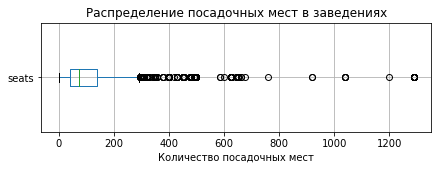

In [47]:
plt.figure(figsize=(7, 2))

df.boxplot(column='seats', vert=False)

plt.title('Распределение посадочных мест в заведениях')
plt.xlabel('Количество посадочных мест')

plt.show()

Распределение несимметричное, скошенное вправо. Минимальное значение равно 0, максимальное равно 1288. В данных имеются аномальные значения, они превосходят отметку в 800, но, скорее всего, это особенность отдельных очень больших ресторанов. Очень много значений-выбросов, при этом удалять их не имеет смысла, так как мы потеряем значительную часть данных, что может повлиять на выводы. Среднее значение равно примерно 88, тогда как медиана равна 60, что говорит о немалом количестве выбросов.

In [49]:
import numpy as np
df_clean = df.copy()
df_clean['seats'] = df_clean['seats'].replace(-1, np.nan)


median_seats = df_clean.groupby('category')['seats'].median().sort_values(ascending=False)

median_seats

category
ресторан           86.0
бар,паб            82.0
кофейня            80.0
столовая           75.5
быстрое питание    65.0
кафе               60.0
пиццерия           55.0
булочная           50.0
Name: seats, dtype: float64

In [50]:
pivot_seats_median = pd.pivot_table(
    df_clean,
    index='category',
    values='seats',
    aggfunc='median'
).sort_values('seats', ascending=False)

pivot_seats_median

,seats
category,
ресторан,86.0
"бар,паб",82.0
кофейня,80.0
столовая,75.5
быстрое питание,65.0
кафе,60.0
пиццерия,55.0
булочная,50.0


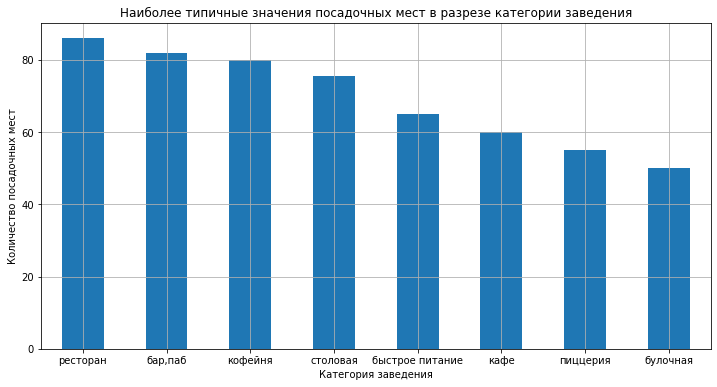

In [51]:
median_seats.plot(kind='bar',
             rot=0,
             legend=False,
             figsize=(12, 6),
             title="Наиболее типичные значения посадочных мест в разрезе категории заведения")
plt.xlabel('Категория заведения')
plt.ylabel('Количество посадочных мест')
plt.grid()
plt.show()

Для категорий `ресторан` и `бар,паб` наиболее типичными оказались значения в 86 и 82 посадочных места соответственно, для `булочная` было зафиксировано минимально-типичное значение посадочных мест среди всех категорий - 50. Была применена именно медиана, так как она корректно отражает среднее (типичное) значение для каждой категории, при этом выбросы на нее не сильно влияют. 

Чем выше длительность пребывания гостя (рестораны, бары), тем больше посадочных мест требуется заведению. Для быстрых форматов (булочные, пиццерии) компактность — это норма и конкурентное преимущество.

### Задача 5

Исследуем рейтинг заведений. Визуализируем распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

In [54]:
df.groupby('category')['rating'].describe()

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
"бар,паб",764.0,4.387691,0.380392,1.1,4.3,4.4,4.6,5.0
булочная,256.0,4.268362,0.386303,1.3,4.2,4.3,4.4,5.0
быстрое питание,603.0,4.050251,0.560949,1.1,3.9,4.2,4.3,5.0
кафе,2376.0,4.124280,0.566003,1.0,4.0,4.2,4.4,5.0
кофейня,1413.0,4.277278,0.372251,1.4,4.1,4.3,4.4,5.0
пиццерия,633.0,4.301267,0.336162,1.0,4.2,4.3,4.4,5.0
ресторан,2042.0,4.290394,0.413142,1.0,4.2,4.3,4.5,5.0
столовая,315.0,4.211428,0.454205,1.0,4.1,4.3,4.4,5.0


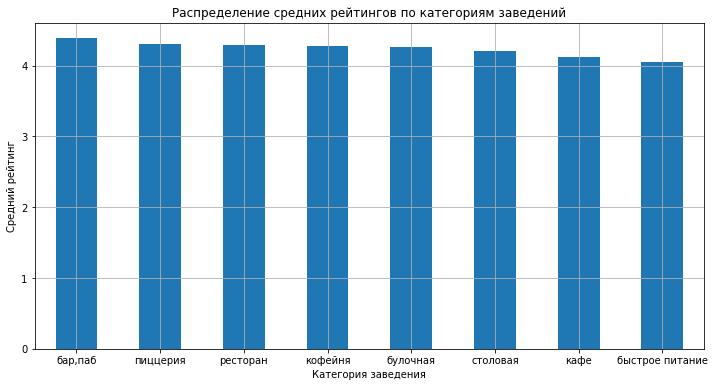

In [53]:
grouped = df.groupby('category')['rating'].mean().sort_values(ascending=False)
grouped.plot(kind='bar',
             rot=0,
             legend=False,
             figsize=(12, 6),
             title="Распределение средних рейтингов по категориям заведений")
plt.xlabel('Категория заведения')
plt.ylabel('Средний рейтинг')
plt.grid()
plt.show()

Средние рейтинги, как видно из визуализации, для каждой категории общепита почти не меняются, что может указывать на незначительную разницу в выборе категории будущего заведения. Можно выбрать любую, рейтинг не сильно зависит от категории.

Бизнес-смысл</b>:
- <b><i>Рекорд баров</i></b>: Если инвестор ищет максимальную лояльность аудитории и защиту от негатива — формат "бар,паб" с завышенной оценкой. Ошибки в сервисе здесь прощают больше, чем в ресторане.
- <b><i>Проблема фастфуда и кафе</i></b>: Рынок этих заведений перегрет и нестабилен. Средняя оценка 4.05 означает, что около половины точек имеют рейтинг ниже 4.0 — это уровень "можно не прийти" для многих гостей. Открывать кафе или фастфуд без четкого стандарта качества или известного бренда очень рискованно.
- <b><i>Столовые</i></b>: Не все столовые дешевые и плохие. Огромный разброс данных (от 1.0 до 5.0) говорит о наличии ниши "премиум-столовых" в бизнес-центрах, которые получают оценки на уровне ресторанов.

<b>Рекомендации</b>
- <b><i>Изучить успешных</i></b>: Стоит отдельно выгрузить бары с рейтингом >4.6 и столовые с рейтингом >4.5, чтобы понять их формулу успеха (меню, акции, расположение).
- <b><i>Избегать "серой зоны"</i></b>: Открывать обычное кафе или рядовую бургерную сейчас невыгодно — конкуренция завалила этот сегмент низкими оценками.
- <b><i>Инвестиции в качество</i></b>: В сегменте "быстрого питания" важна не цена, а стабильность. Учитывая высокий стандартный разброс отметок, заведение с четким сервисом (рейтинг 4.5+) легко вырвется вперед, так как средняя температура по больнице низкая.</font>

### Задача 6

Изучим, с какими данными показывают самую сильную корреляцию рейтинги заведений. Построим и визуализируем матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберем самую сильную связь и проверим её.

In [57]:
print(df[['seats', 'rating']].corr())

print(df_clean[['seats', 'rating']].corr())

           seats    rating
seats   1.000000  0.021109
rating  0.021109  1.000000
           seats    rating
seats   1.000000  0.021109
rating  0.021109  1.000000


In [58]:
correlation_matrix = df_clean[['category', 'district', 'chain', 'seats', 'price', 'is_24_7', 'rating']].phik_matrix() 
print('Корреляционная матрица с коэффициентом phi_k для переменной rating')
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['chain', 'seats', 'rating']
Корреляционная матрица с коэффициентом phi_k для переменной rating


,rating
price,0.262056
category,0.198739
district,0.189453
is_24_7,0.161010
chain,0.118857
seats,0.000000


Судя по корреляционной матрице, самая сильная связь рейтинга заведения наблюдается именно с ценовой категорией, именно ее мы и будем проверять.

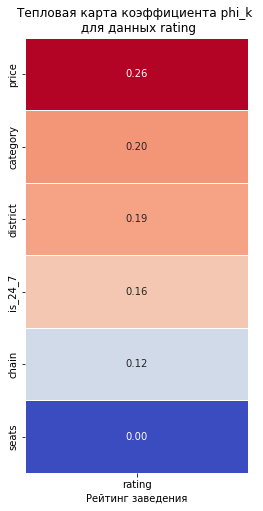

In [59]:
plt.figure(figsize=(4, 8))

data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(data_heatmap,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            cbar=False
           )

plt.title('Тепловая карта коэффициента phi_k \n для данных rating')
plt.xlabel('Рейтинг заведения')

plt.show()

In [60]:
pivot_rat = pd.pivot_table(
df_clean,
index='price',
values='rating',
aggfunc='mean').sort_values('rating', ascending=False)
pivot_rat

,rating
price,
высокие,4.436611
выше среднего,4.386348
средние,4.297874
низкие,4.173077


- Высокие значения рейтинга (>4,38) получили категории цен `высокие` и `выше среднего`
- Также видно, что чем меньше ценовая категория, тем меньше средний рейтинг клиентов

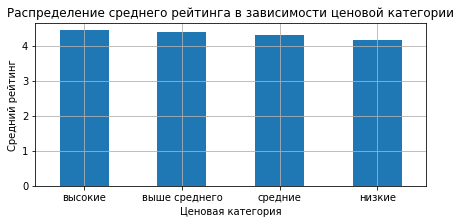

In [61]:
grouped = df_clean.groupby('price')['rating'].mean().sort_values(ascending=False)
grouped.plot(kind='bar',
               title=f'Распределение среднего рейтинга в зависимости ценовой категории',
               legend=False,
               ylabel='Средний рейтинг',
               xlabel='Ценовая категория',
               rot=0,
               figsize=(7, 3))
plt.grid()

plt.show()


- На столбчатой диаграмме видно, что средний рейтинг заведения не сильно меняется в зависимости от ценовой категории. На самом деле это ожидаемо, коэффициент корреляции phik хоть и самый большой среди представленных, но при этом все равно по модулю слишком маленький, чтобы связь была сильной (0,26)
- Однако связь все же есть, и при решении вопроса, заведение какой ценовой категории открывать, будет понятно, что чем выше желаемый рейтинг, тем выше должны быть цены

Бизнес-интерпретация:
- Для владельца заведения:<br>
Если вы позиционируетесь в низком ценовом сегменте — будьте готовы, что рейтинги в среднем будут ниже. Это не означает, что у вас плохое заведение, просто аудитория низкого сегмента более требовательна или чаще оставляет негативные отзывы.
Для достижения высоких рейтингов важно не только качество, но и соответствие ожиданиям, которые формируются ценой.

- Для инвестора:<br>
Премиальный сегмент (высокие цены) в среднем получает более высокие оценки — возможно, здесь меньше конкуренция за рейтинг или клиенты более лояльны.
Инвестиции в дорогие заведения статистически оправданы с точки зрения репутации.

- Для аналитика:<br>
Цена — самый важный фактор среди всех проанализированных, но корреляция 0.26 говорит о том, что он объясняет лишь часть вариации рейтинга. Остальное — другие факторы (кухня, сервис, расположение), которые не вошли в анализ.
Рекомендуется дополнить анализ исследованием неценовых факторов.
</font>

### Задача 7

Сгруппируем данные по названиям заведений и найдем топ-15 популярных сетей в Москве. Для них посчитаем значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводим подходящими визуализациями.

In [62]:
top_names_cat = df_clean[df_clean['chain'] == 1].groupby(['name', 'category']).size().reset_index(name='count')
top_names_cat = top_names_cat.sort_values('count', ascending=False).head(15)

pivot_7 = df_clean[(df_clean['chain'] == 1) & 
                   (df_clean[['name', 'category']].apply(tuple, axis=1).isin(
                    top_names_cat[['name', 'category']].apply(tuple, axis=1)))].groupby(['name', 'category']).agg(
    count_object=('id', 'count'),
    mean_rating=('rating', 'mean')
).sort_values('count_object', ascending=False)

pivot_7

,,count_object,mean_rating
name,category,,
шоколадница,кофейня,119,4.178151
домино'с пицца,пиццерия,76,4.169737
додо пицца,пиццерия,74,4.286487
one price coffee,кофейня,71,4.064789
яндекс лавка,ресторан,69,3.872464
cofix,кофейня,65,4.075385
prime,ресторан,49,4.114285
кофепорт,кофейня,42,4.147619
кулинарная лавка братьев караваевых,кафе,39,4.394872


У самых распорстраненных сетей встречаются такие категории: кофейня, пиццерия, ресторан, быстрое питание, кафе и булочная. Причем на кофейня приходится треть лидеров

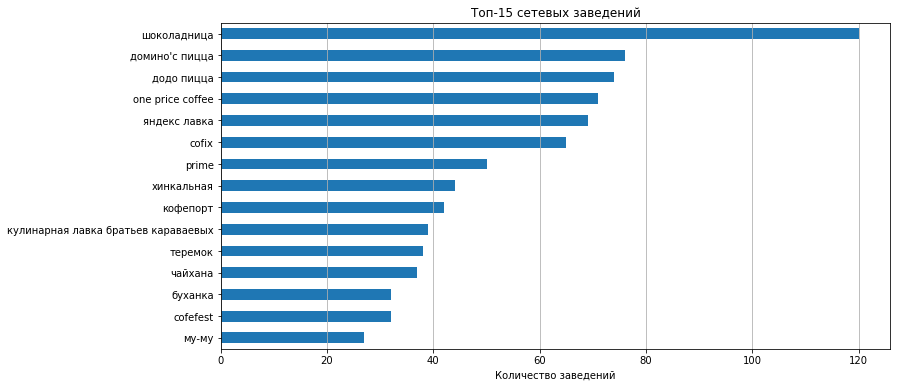

In [63]:
df_clean[df_clean['chain'] == 1]['name'].value_counts().head(15).sort_values().plot(kind='barh', figsize=(12, 6))
plt.xlabel('Количество заведений')
plt.title('Топ-15 сетевых заведений')
plt.grid(axis='x')
plt.show()

Было найдено топ-15 самых популярных сетей в Москве и построена соответствующая визуализация. Лидером по популярности стала сеть шоколадница, второе место заняла домино'с пицца, а в топ-3 вошла додо пицца.

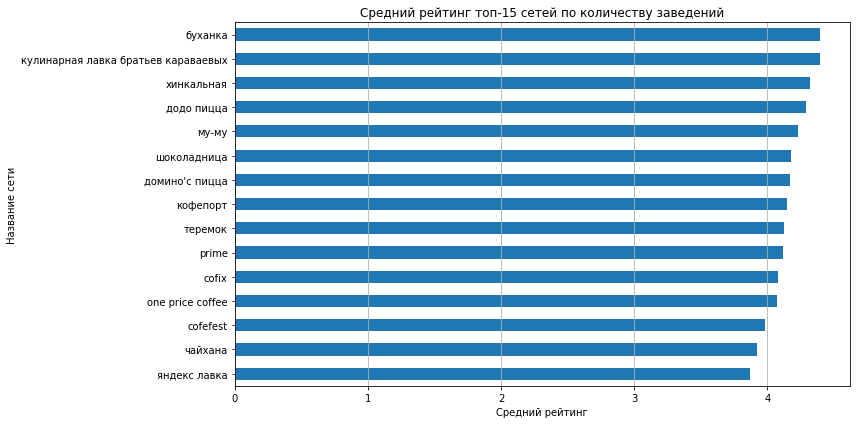

In [64]:
top15_names = df[df['chain'] == 1]['name'].value_counts().head(15).index
top15_rating = df[df['name'].isin(top15_names)].groupby('name')['rating'].mean().sort_values()
top15_rating.plot(kind='barh',
                  figsize=(12, 6),
                  title="Средний рейтинг топ-15 сетей по количеству заведений")
plt.xlabel('Средний рейтинг')
plt.ylabel('Название сети')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

Самый высокий средний рейтинг среди наиболее популярных сетей Москвы оказался у буханка, при этом самый низкий рейтинг из представленных сетевых заведений - у яндекс лавка

Мы понимаем, что у некоторых сетей множество категорий заведений, что указывает на политику расширения по разным форматам.

Ключевые бизнес-выводы:
- Масштаб <b>≠</b> высокое качество: крупнейшие сети не всегда лидируют по рейтингу.
- Нишевые сети с высоким качеством (Буханка, Кофемания) могут успешно конкурировать, делая ставку на качество, а не на количество.
- Зона риска: сети с большим количеством заведений и низким рейтингом (Яндекс Лавка) требуют внимания к качеству обслуживания.
- Золотая середина: Додо Пицца демонстрирует успешную стратегию масштабирования без потери качества.</font>

### Задача 8

Изучим вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируем цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводим подходящими визуализациями.

In [72]:
grouped8 = df.groupby('district')['middle_avg_bill'].agg(['median', 'mean']).reset_index()
grouped8

,district,median,mean
0,Восточный административный округ,575.0,820.626953
1,Западный административный округ,1000.0,1053.225464
2,Северный административный округ,650.0,927.959656
3,Северо-Восточный административный округ,500.0,716.611267
4,Северо-Западный административный округ,700.0,822.222900
5,Центральный административный округ,1000.0,1191.057495
6,Юго-Восточный административный округ,450.0,654.097961
7,Юго-Западный административный округ,600.0,792.561707
8,Южный административный округ,500.0,834.398071


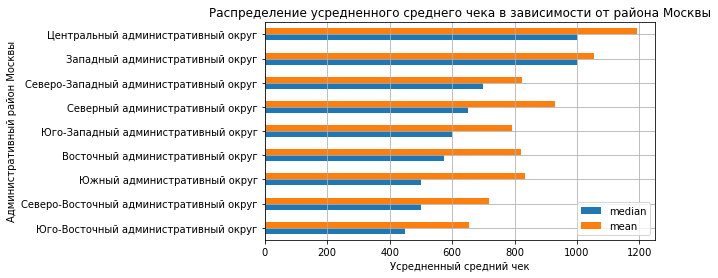

In [81]:
gr = df.groupby('district')['middle_avg_bill'].agg(['median', 'mean']).sort_values(by='median', ascending=True).plot(kind='barh',
              title=f'Распределение усредненного среднего чека в зависимости от района Москвы',
              legend=True,
              ylabel='Усредненный средний чек',
              xlabel='Административный район Москвы',
              rot=0,
              figsize=(7, 4))
gr.set_xlabel('Усредненный средний чек')
gr.set_ylabel('Административный район Москвы')
plt.grid()

plt.show()

Как видно из графика, в ЦАО самые большие усредненные средние чеки, при удалении от центра цены падают.

In [82]:
grouped8 = df.groupby('district')['middle_avg_bill'].max().sort_values(ascending=False)
grouped8

district
Южный административный округ               35000.0
Северный административный округ            11000.0
Восточный административный округ           10000.0
Центральный административный округ          7250.0
Западный административный округ             5250.0
Северо-Восточный административный округ     4500.0
Юго-Восточный административный округ        3750.0
Северо-Западный административный округ      2900.0
Юго-Западный административный округ         2750.0
Name: middle_avg_bill, dtype: float32

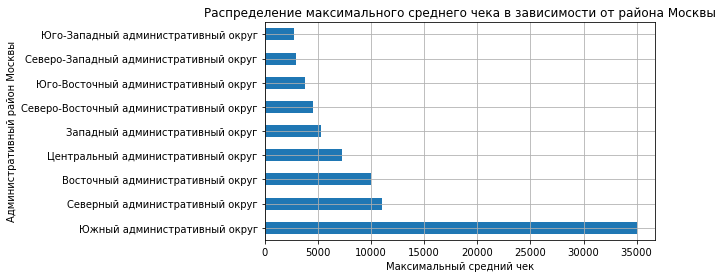

In [83]:
gr = grouped8.plot(kind='barh',
              title=f'Распределение максимального среднего чека в зависимости от района Москвы',
              legend=False,
              ylabel='Усредненный средний чек',
              xlabel='Административный район Москвы',
              rot=0,
              figsize=(7, 4))
gr.set_xlabel('Максимальный средний чек')
gr.set_ylabel('Административный район Москвы')
plt.grid()

plt.show()

Как видим, минимальный средний чек, отличный от нуля, оказался в Юго-Восточном АО. Значение 0 в ЦАО говорит скорее всего об особенности данных именно в этом районе, например, могли закрыть счет на 0 в честь дня рождения (небольшое блюдо) или по какому-то другому поводу за счет заведения, но зарегистрировать как стандартный чек.

Удалённость от центра является прямым драйвером снижения цены: чем дальше, тем дешевле.<br>

1. <b>ЦАО — ценовой эталон с максимальной премией:</b>
- Центр Москвы (ЦАО) диктует максимальные цены на рынке: <b>средний чек здесь составляет 1190 ₽ (медиана — 1000 ₽)</b>. Это делает ЦАО единственным округом, преодолевшим порог в 1100 ₽.

2. <b>Эффект «ценового плато» и резкого спада:</b><br>
Влияние удалённости нелинейно:
- <b>Ближний пояс (ЗАО):</b> Практически не уступает центру (средний чек — 1053 ₽, медиана — 1000 ₽). Удалённость на 5–10 км от Кремля <b>почти не снижает цену</b>.
- <b>Средний пояс (САО, СЗАО, ЮАО, ВАО, ЮЗАО, СВАО):</b> Происходит обвал на <b>20–35%</b>. Средний чек падает до уровня <b>715–830 ₽</b>.
- <b>Дальний пояс (ЮВАО): <b>Максимальное влияние удалённости. Цены падают до <b>654 ₽ (средний)</b> и <b>450 ₽ (медиана)</b>. Это <b>почти вдвое ниже</b>, чем в ЦАО.

3. <b>Бизнес-смысл:</b>
- <b>Окупаемость через цену:</b> При запуске в ЦАО и ЗАО следует закладывать наценку +30–50% к себестоимости — рынок её примет.
- <b>Окупаемость через объём:</b> В ЮВАО, ЮАО, СВАО полагаться на высокий чек нельзя. Успех решает только <b>проходимость и демократичная цена</b> (ориентир — медиана 450–600 ₽).

4. <b>Рекомендация:</b>
- Если концепция заведения предполагает цену чека выше 1000 ₽, <b>открывайтесь строго в ЦАО или на западе (ЗАО)</b>. При запуске в любом другом округе (кроме ЗАО) расчётная цена должна быть не выше 700–800 ₽, иначе заведение проиграет конкурентам по соотношению «цена-качество».
</font>

### Промежуточный вывод


- Самая популярная категория заведений в Москве - `кафе`.
- Больше всего заведений в ЦАО, при этом самый популярный вид - `ресторан`.
- Больше в Москве именно несетевых заведений, при этом самые популярные категории среди сетевых тоже `булочная` и `пиццерия`.

- Для категорий `ресторан` и `бар,паб` наиболее типичными оказались значения в 86 и 82 посадочных места соответственно. 
- Категория заведений почти не влияет на среднюю оценку клиентов.
- Средний рейтинг слабо, но зависит от ценовой категории: чем выше ценовая категория, тем выше средний рейтинг.

- Было найдено топ-15 самых популярных сетей в Москве. Лидером по популярности стала сеть `шоколадница`, второе место заняла `домино'с пицца`, а в топ-3 вошла `додо пицца`.
- Наибольший средний чек, усредненный по всем ресторанам в конкретном районе, наблюдается именно в ЦАО.
- С большим отрывом максимальный средний чек был выявлен у заведений в Южном АО.

## 4. Итоговый вывод и рекомендации


В процессе работы были изучены предложенные данные об общепитах Москвы, проведена предварительная обработка этих данных.
Проведен исследовательский анализ данных, в процессе которого изучались закономерности и взаимосвязи между признаками, влияющими на различные метрики заведений.

Кафе, ресторан и кофейни - вот самые популярные заведения в столице. Зависимости между типом заведения и средним рейтингом почти не обнаружилось, поэтому не нужно ориентироваться на категорию - рейтинги будут примерно одинаковыми. Наиболее популярное количество посадочных в размере 100 штук оказалось именно у кофеен и ресторанов, что является рекордом среди других категорий по количеству посадочных мест. Если интересует большое заведение на много гостей - ресторан или кофейня - отличный выбор.

Наибольшее количество заведений располагается именно в ЦАО, там же в среднем средний чек по ресторанам будет больше, поэтому в этом районе можно рассчитывать на большую прибыль по сравнению с другими. 

Больше всего в Москве именно несетевых заведений примерно на 2000 по сравнению с сетевыми, так что ниша сетевых заведений еще не так загружена и можно рассмотреть идею об открытии именно сети общепита.

Так как в столице наиболее популярны рестораны, кафе и кофейни, то значит имеет смысл открыть что-то из этого. Высокая популярность - показатель спроса, людям нужны такие заведения больше, чем другие. В ЦАО буду самые высокие средние чеки, но и конкуренция также будет выше. Можно рассмотреть возможность открытия сети ресторанов или кофеен с разнообразным количеством посадочных мест (от 20 до 100) и в Северном АО, Западном АО и Южном АО, там тоже высокие средние чеки, но при этом рынок мест общественного питания не так перегрет. Амбициознее конечно открыться в ЦАО, но нужно учитывать конкуренцию и быть готовым предоставлять очень качественные услуги по питанию, ценовая категория блюда должна быть высокой, так можно рассчитывать на самые высокие оценки клиентов.